# Ableitung mehrere Variablen


## Übungsblatt


In [6]:
import numpy as np
import matplotlib.pyplot as plt

### Aufgabe 1: Partielle Ableitungen berechnen


Hier geht es um die Funktion $f(x,y) = x^2  - 2y^2$.


#### a) Von Hand


Berechne von Hand die beiden partiellen Ableitungen $f_x(x,y)$ und $f_y(x,y)$ und werte beide an der Stelle $(x,y)=(1,3)$ aus.


#### b) Numerisch


Berechne die beiden partiellen Ableitungen an der Stelle $(x,y)=(1,3)$ mithilfe der numerischen Approximation (siehe Vertiefung).


In [7]:
def f(x, y):
    return x**2 - 2 * y**2


def partial_x(f, x, y, h=1e-5):
    return (f(x + h, y) - f(x - h, y)) / (2 * h)


def partial_y(f, x, y, h=5e-6):
    return (f(x, y + h) - f(x, y - h)) / (2 * h)


x, y = 1, 3

numapprox_x = partial_x(f, x, y)
numapprox_y = partial_y(f, x, y)

numapprox_x, numapprox_y

(2.0000000001019203, -11.999999999545706)

### Aufgabe 2: Gradient numerisch berechnen


#### a) Implementierung


Implementiere eine Funktion `gradient_2d(f, x, y, h=5e-6)`, die den Gradienten einer beliebigen Funktion `f(x,y)` an der Stelle $(x,y)$ berechnet. Die Funktion soll die beiden partiellen Ableitungen numerisch berechnen und den Gradienten als NumPy Array zurückgeben.


In [8]:
def gradient_2d(f, x, y, h=1e-5):
    return np.array(
        [
            (f(x + h, y) - f(x - h, y)) / (2 * h),
            (f(x, y + h) - f(x, y - h)) / (2 * h),
        ]
    )

#### b) Test


Teste die Funktion mit der Funktion $f(x,y) = x^2  - 2y^2$ an der Stelle $(x,y)=(1,3)$ und vergleiche mit der analytischen Rechnung (von Hand).


In [10]:
def f(x, y):
    return x**2 - 2 * y**2


list(gradient_2d(f, 1, 3, h=5e-6))

[np.float64(1.9999999999242843), np.float64(-11.999999999545706)]

#### c) Darstellung


Stelle den Gradienten der Funktion $f(x,y) = x^2  - 2y^2$ im Bereich $x \in [-2,2]$ und $y \in [-1.5,1.5]$ dar. Verwende

-   [`np.linspace`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html) und [`np.meshgrid`](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html) für das Erstellen der $x$- und $y$-Gitterpunkte,
-   `gradient_2d` für das Berechnen des Gradienten an den Gitterpunkten und
-   [`plt.quiver`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.quiver.html) für das Darstellen des Gradienten als Pfeile.

**Hinweis:** Erzeuge nicht zu viele Gitterpunkte, da die Gradientenpfleile sonst zu dicht und klein werden.

**Option 1:** Als fünftes Argument von [`plt.quiver`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.quiver.html) kann die Farbe der Pfeile angegeben werden. Verwende die Funktionswerte $z=f(x,y)$ als Farbe der Pfeile.

**Option 2:** Ersetze [`plt.quiver`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.quiver.html) durch [`plt.streamplot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.streamplot.html), um den Gradienten als Stömungsfeld zu visualisieren.


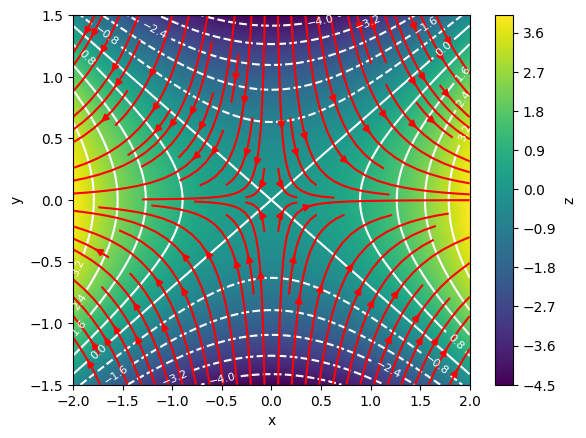

In [21]:
n = 200
x = np.linspace(-2, 2, n)
y = np.linspace(-1.5, 1.5, n)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

grad_y, grad_x = np.gradient(Z, y, x)

plt.contourf(X, Y, Z, levels=200)
plt.colorbar(label="z")
cs = plt.contour(X, Y, Z, levels=10, colors="w")
plt.clabel(cs, fontsize=8)

# step = n // 13
# plt.quiver(
#     X[::step, ::step],
#     Y[::step, ::step],
#     grad_x[::step, ::step],
#     grad_y[::step, ::step],
#     angles="xy",
#     color="r",
# )

plt.streamplot(X, Y, grad_x, grad_y, color="r")

plt.xlabel("x")
plt.ylabel("y")
plt.show()

### Aufgabe 3: Höhenlinien und Gradient zusammen darstellen


Gegeben sei die Funktion

$$
    g(x,y) = y \cdot e^{-x^2}
$$

1. Stelle die Höhenlinien im Bereich $x, y \in [-2,2]$ mit $200\!\times\!200$ Punkten dar.
2. Zeichne zusätzlich den Gradienten an $15\!\times\!15$ ein.

Hierfür solltest du folgende Funktion verwernden:

-   [`np.linspace`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html)
-   [`np.meshgrid`](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html)
-   [`plt.contourf`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contourf.html)
-   [`np.gradient`](https://numpy.org/doc/stable/reference/generated/numpy.gradient.html)
-   [`plt.quiver`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.quiver.html)

Wenn du weniger Punkte für den [`np.linspace`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html) verwendest, dann bekommst du auch weniger Gradienten-Pfeile und sie werden etwas länger (und somit grösser) dargestellt. Probiere es aus.


### Aufgabe 4: Gradientenverfahren in 2D


Hier ist die Implementation des Gradientenverfahrens aus der Vertiefung:


Nun soll ein Minimum der folgenden Funktion bestimmt werden:

$$ f(x,y) = x^4 + \frac{1}{2}y^4 - 2x^2 - 3y^2 + x(y-1) + 10 $$

1. Bestimme den Gradienten der Funktion analytisch von Hand. Überprüfe dein Resultat mithilfe von [Wolfram|Alpha](https://www.wolframalpha.com/). Beispiel: https://www.wolframalpha.com/input?i=gradient+of+x%5Ey
2. Nutze die Funktion `gradient_descent_2d` von oben, um das Minimum (bzw. eines der Minima) zu finden.
3. Stelle die Höhenlinien im Bereich $x \in [-2,2]$ und $y \in [-3,3]$ dar.
4. Visualiere den Verlauf des Gradientenverfahrens (analog zur Vertiefung)
5. Experimentiere mit verschiedenen Startwerten und Lernraten.

**Tipp:** Mithilfe von [Wolfram|Alpha](https://www.wolframalpha.com/) kannst du zum Vergleich das Minimum der Funktion auch bestimmen (_minimize ..._).

**Optional:** Stelle den Gradienten der Funktion auch noch dar.


### Aufgabe 5: Gradientenverfahren in 1D (optional)


#### a) Wie funktioniert das Gradientenverfahren?


Schreibe Schritt für Schritt auf, wie das Gradientenverfahren funktioniert und was die Rollen der Parameter sind. Analysiere dazu die Implementierung in der Funktion `gradient_descent_2d`.


#### b) Implementierung in 1D


Implementiere das Gradientenverfahren in 1D. Dazu kannst Du die Funktion `gradient_descent_2d` von oben als Vorlage nutzen. Nenne die neue Funktion `gradient_descent_1d`. Diese soll wieder eine Liste der Zwischenwerte und deren Fehlerabschätzung zurückgeben.


#### c) Test


Teste die Implementierung mit der Funktion

$$
    f(x) = x^2 - 6x
$$

Probiere unterschiedliche Startwerte `x0` im Bereich von $\left[-10,10\right]$ und alpha Werte im Intervall $\left]0,1\right[$ aus. Beschreibe welchen Einfluss `x0` und `alpha` auf das Verhalten des Algorithmus haben.

Um den Verlauf des Gradientenverfahrens zu visualisieren, kannst du z.B. die Folge der $x$-Werte mit `plt.plot` oder `plt.stem` darstellen.


Eine spannende Darstellung könnte auch so aussehen. Hier sind `xs` die $x$-Werte aus dem Resultat des Gradientenverfahrens.

Dann wird die Funktion $f(x)$ dargestellt und darauf die Punkte $(x_i,f(x_i))$, die beim Gradientenverfahren durchlaufen werden, markiert, nummeriert und mit Pfeilen verbunden.


#### d) Verfahren mehrmals durchführen und Resultate vergleichen


Nun soll das Gradientenverfahren mehrmals durchgeführt werden und die Resultate verglichen werden.

Dazu soll eine Liste von `x0`-Werten und eine Liste von unterschiedlichen `alpha`-Werten gegeben werden. Für jede Kombination soll das Gradientenverfahren ausgeführt und die Resultate in einem Subplot dargestellt werden.

Entscheide selbst, ob du die Darstellung des Verlaufs der x-Werte (mit `plt.stem`) oder die Darstellung der Punkte in der Zielfunktion (mit `plt.plot`) bevorzugst.
